# Ejercicio 1: Introducción a Recuperación de Información

## Objetivo de la práctica
- Entender el problema de **buscar información** en colecciones de texto.
- Comprender por qué se necesita un **índice invertido** en recuperación de información.
- Programar una primera solución manual y luego optimizarla con un índice.
- Evaluar la mejora en tiempos de búsqueda cuando usamos estructuras adecuadas.

## Parte 1: Búsqueda lineal en documentos

### Actividad
1. Se te proporcionará un dataset con reviews de películas.
2. Escribe una función que:
   - Lea todos los documentos.
   - Busque una palabra ingresada por el usuario.
   - Muestre en qué documentos aparece la palabra.

In [16]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import time
import re
from collections import defaultdict
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv
/kaggle/input/clapper-massive-rotten-tomatoes-movies-and-reviews/rotten_tomatoes_movies.csv
/kaggle/input/clapper-massive-rotten-tomatoes-movies-and-reviews/rotten_tomatoes_movie_reviews.csv


In [18]:
path = '/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv'
df = pd.read_csv(path)
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [10]:
def busqueda_lineal(df, palabra):
    palabra = palabra.lower()  # Normalizamos a minúsculas
    resultados = []
    
    for i, review in enumerate(df['review']):
        if palabra in review.lower():  # Buscamos la palabra en minúsculas
            resultados.append(i)
    
    if resultados:
        print(f"La palabra '{palabra}' aparece en los siguientes documentos (índices):")
        print(resultados)
    else:
        print(f"La palabra '{palabra}' no se encontró en ningún documento.")


In [11]:
palabra_usuario = input("Ingresa la palabra a buscar: ")
busqueda_lineal(df, palabra_usuario)


Ingresa la palabra a buscar:  good


La palabra 'good' aparece en los siguientes documentos (índices):
[4, 12, 13, 14, 19, 20, 21, 24, 25, 26, 28, 29, 32, 33, 38, 40, 43, 45, 46, 50, 51, 58, 59, 64, 67, 68, 69, 70, 71, 74, 77, 82, 83, 85, 86, 88, 89, 91, 92, 96, 97, 99, 101, 102, 105, 107, 111, 122, 125, 126, 128, 131, 134, 135, 137, 138, 139, 140, 145, 146, 158, 159, 165, 168, 171, 177, 178, 181, 186, 188, 189, 195, 197, 198, 200, 202, 206, 214, 215, 216, 217, 225, 227, 232, 234, 236, 240, 241, 243, 248, 250, 256, 258, 263, 267, 273, 275, 279, 280, 287, 288, 289, 295, 296, 297, 298, 301, 309, 310, 313, 314, 320, 321, 322, 323, 329, 330, 332, 337, 338, 341, 345, 349, 350, 351, 353, 354, 355, 356, 357, 359, 361, 362, 364, 365, 369, 370, 374, 378, 381, 385, 389, 393, 394, 395, 400, 408, 410, 411, 414, 415, 416, 417, 418, 419, 424, 426, 427, 430, 433, 434, 435, 436, 439, 440, 442, 445, 447, 454, 456, 457, 459, 461, 463, 465, 468, 470, 473, 474, 476, 478, 480, 481, 485, 486, 487, 494, 497, 499, 504, 507, 508, 513, 514, 516, 5

# Parte 2: Construcción de un índice invertido
# # Actividad


*     Escribe un programa que:
* Recorra todos los documentos.
* Construya un índice invertido, es decir, un diccionario donde:            Cada palabra clave apunta a una lista de documentos donde aparece.
* Escribe una nueva función de búsqueda que:        Consulte directamente el índice para encontrar los documentos relevantes.
* Sea mucho más rápida que la búsqueda lineal.




In [20]:
def construir_indice(df):
    indice = defaultdict(dict)  # Cada palabra -> {doc_id: frecuencia}

    for i, review in enumerate(df['review']):
        # Convertimos a minúsculas y separamos palabras eliminando puntuación
        palabras = re.findall(r'\b\w+\b', review.lower())
        for palabra in palabras:
            if i in indice[palabra]:
                indice[palabra][i] += 1
            else:
                indice[palabra][i] = 1
    
    return indice

In [21]:
indice_invertido = construir_indice(df)
print("Número de palabras únicas en el índice:", len(indice_invertido))


Número de palabras únicas en el índice: 101944


In [22]:
def busqueda_indice(indice, palabra):
    palabra = palabra.lower().strip('.,!?()[]{}":;')
    if palabra in indice:
        resultados = list(indice[palabra])
        print(f"La palabra '{palabra}' aparece en los siguientes documentos (índices):")
        print(resultados)
    else:
        print(f"La palabra '{palabra}' no se encontró en ningún documento.")


In [23]:
palabra_usuario = input("Ingresa la palabra a buscar: ")
busqueda_indice(indice_invertido, palabra_usuario)


Ingresa la palabra a buscar:  good


La palabra 'good' aparece en los siguientes documentos (índices):
[4, 12, 13, 14, 19, 20, 21, 24, 25, 26, 28, 29, 32, 38, 40, 43, 45, 46, 50, 51, 58, 59, 64, 67, 68, 69, 70, 71, 77, 82, 83, 85, 86, 88, 89, 91, 92, 96, 97, 99, 101, 102, 105, 107, 111, 122, 125, 126, 128, 131, 134, 135, 137, 138, 139, 140, 145, 146, 158, 159, 165, 168, 171, 177, 178, 181, 186, 188, 189, 195, 197, 198, 200, 202, 206, 214, 215, 216, 217, 225, 227, 232, 234, 236, 240, 241, 243, 248, 250, 256, 258, 263, 267, 273, 275, 279, 280, 287, 288, 289, 295, 296, 297, 298, 301, 309, 310, 313, 314, 320, 322, 323, 329, 330, 332, 337, 338, 341, 345, 349, 350, 351, 353, 354, 355, 356, 357, 361, 362, 364, 365, 369, 370, 374, 378, 381, 385, 389, 393, 394, 395, 408, 411, 414, 415, 416, 417, 418, 419, 424, 426, 427, 430, 433, 434, 435, 436, 439, 440, 442, 445, 447, 456, 457, 459, 461, 463, 465, 468, 470, 473, 474, 478, 480, 481, 485, 486, 487, 494, 497, 499, 504, 507, 508, 513, 514, 516, 519, 526, 534, 539, 540, 543, 547, 550,


# Parte 3: Evaluación de tiempos de búsqueda# 
# Actividad# 

    Realiza la búsqueda de varias palabras usando:
        Corpus pequeño.
        Corpus grande.
    Mide el tiempo de ejecución:
        Para búsqueda lineal.
        Para búsqueda usando índice invertido.
        Grafica o presenta los resultados en una tabla comparativa.



In [25]:
import pandas as pd
import re
from collections import defaultdict
import time
import matplotlib.pyplot as plt


In [26]:
def busqueda_lineal_timed(df, palabra):
    start_time = time.time()
    palabra = palabra.lower()
    resultados = []

    for i, review in enumerate(df['review']):
        if palabra in review.lower():
            resultados.append(i)

    elapsed_time = time.time() - start_time
    return resultados, elapsed_time


In [45]:
import re
from collections import defaultdict

def construir_indice(df, columna_texto='review'):
    indice = defaultdict(dict)
    for i, review in enumerate(df[columna_texto]):
        # Convertir a string y manejar valores nulos
        review = str(review) if not pd.isnull(review) else ''
        palabras = re.findall(r'\b\w+\b', review.lower())
        for palabra in palabras:
            if i in indice[palabra]:
                indice[palabra][i] += 1
            else:
                indice[palabra][i] = 1
    return indice



In [49]:
def busqueda_lineal_timed(df, palabra, columna_texto='review'):
    import time
    start_time = time.time()
    palabra = palabra.lower()
    resultados = []

    for i, review in enumerate(df[columna_texto]):
        # Convertir a string por si hay NaN
        review = str(review) if not pd.isnull(review) else ''
        if palabra in review.lower():
            resultados.append(i)

    elapsed_time = time.time() - start_time
    return resultados, elapsed_time



In [40]:
# Corpus pequeño
path_small = '/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv'
df_small = pd.read_csv(path_small)

# Corpus grande
path_large = '/kaggle/input/clapper-massive-rotten-tomatoes-movies-and-reviews/rotten_tomatoes_movie_reviews.csv'
df_large = pd.read_csv(path_large)



In [47]:
# Corpus pequeño (IMDB)
indice_small = construir_indice(df_small, columna_texto='review')

# Corpus grande (Rotten Tomatoes)
indice_large = construir_indice(df_large, columna_texto='reviewText')


In [50]:
palabras_prueba = ['good', 'bad', 'excellent', 'boring', 'love']
resultados_comparacion = []

for palabra in palabras_prueba:
    # Corpus pequeño
    res_lin_small, time_lin_small = busqueda_lineal_timed(df_small, palabra, columna_texto='review')
    res_ind_small, time_ind_small = busqueda_indice_timed(indice_small, palabra)
    
    # Corpus grande
    res_lin_large, time_lin_large = busqueda_lineal_timed(df_large, palabra, columna_texto='reviewText')
    res_ind_large, time_ind_large = busqueda_indice_timed(indice_large, palabra)
    
    resultados_comparacion.append({
        'palabra': palabra,
        'time_lin_small': time_lin_small,
        'time_ind_small': time_ind_small,
        'time_lin_large': time_lin_large,
        'time_ind_large': time_ind_large
    })

df_tiempos = pd.DataFrame(resultados_comparacion)
print(df_tiempos)


     palabra  time_lin_small  time_ind_small  time_lin_large  time_ind_large
0       good        0.241450        0.000006        1.177262        0.000005
1        bad        0.245731        0.000007        1.275881        0.000007
2  excellent        0.258721        0.000006        1.228807        0.000006
3     boring        0.258364        0.000007        1.260028        0.000005
4       love        0.273563        0.000005        1.325706        0.000005


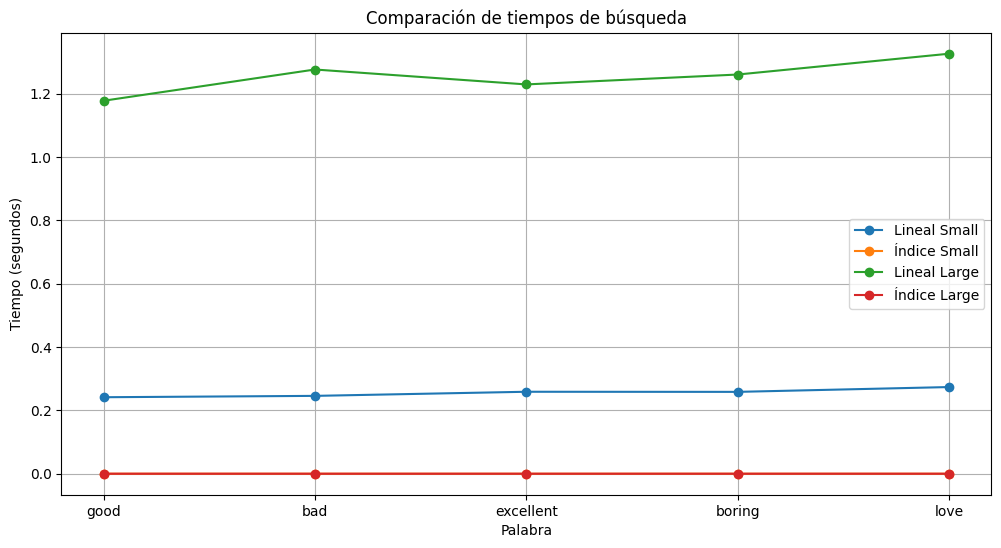

In [51]:
# Graficar tiempos de búsqueda
x = df_tiempos['palabra']

plt.figure(figsize=(12,6))
plt.plot(x, df_tiempos['time_lin_small'], marker='o', label='Lineal Small')
plt.plot(x, df_tiempos['time_ind_small'], marker='o', label='Índice Small')
plt.plot(x, df_tiempos['time_lin_large'], marker='o', label='Lineal Large')
plt.plot(x, df_tiempos['time_ind_large'], marker='o', label='Índice Large')

plt.title("Comparación de tiempos de búsqueda")
plt.xlabel("Palabra")
plt.ylabel("Tiempo (segundos)")
plt.legend()
plt.grid(True)
plt.show()
